# Q-Regime
## Small-Data Quantum Kernel Learning for Financial Volatility Regime Classification

This notebook contains the final reproducible pipeline for comparing
classical and quantum kernel methods for short-horizon S&P 500
volatility-regime classification.

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    f1_score,
    recall_score,
)

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
import time



### Volatility data source

The original experiments used Bloomberg Garman-Klass historical volatility for validation against an institutional data source.

Because Bloomberg data cannot be redistributed publicly, the notebook includes a reproducible fallback that computes 5-day and 20-day Garman-Klass volatility directly from public S&P 500 OHLC data downloaded with `yfinance`.

If the Bloomberg file is available locally, it is used. Otherwise, the public Garman-Klass reconstruction is used automatically.

In [15]:
# Preprocessing and feature engineering parameters
# Modeling parameters will be defined later in the notebook

START_DATE = "2010-01-01"
END_DATE = "2025-01-01"

TRAIN_PERIOD = ["2010-01-01", "2020-12-31"] #2010-2020
VAL_PERIOD = ["2021-01-01", "2022-12-31"] # 2021-2022
TEST_PERIOD = ["2023-01-01", "2024-12-31"] # 2023-2024

H= 5 # Prediction horizon
QUANTILE_THRESHOLD = 0.67 # Threshold for high volatility regime

# Reproducibility / runtime control
RUN_EXPENSIVE_QUANTUM = False

SAVED_RESULTS_SOURCE = "Bloomberg"

RUN_OPTIONAL_MACRO_EXTENSION = False

# Results
GLOBAL_SUMMARY = []
MACRO_GLOBAL_SUMMARY = []

RESULTS = []
MACRO_RESULTS = []

# Source and output directories
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
for d in (PROCESSED_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)
BLOOMBERG_VOL_FILENAME = PROCESSED_DIR / "spx_bloomberg_gk_volatility.csv" 

#### Utility functions

In [16]:
def reset_results():
    global GLOBAL_SUMMARY, MACRO_GLOBAL_SUMMARY, RESULTS, MACRO_RESULTS
    GLOBAL_SUMMARY = []
    MACRO_GLOBAL_SUMMARY = []
    RESULTS = []
    MACRO_RESULTS = []

In [17]:
# SUMMARY METRICS
BALANCED_ACCURACY = "Balanced Accuracy"
ROC_AUC = "ROC-AUC"
F1 = "F1"
RECALL_HIGH_VOL = "Recall High Volatility"

DATA_REGIME = "Data Regime"
MODEL_NAME = "Model"
SPLIT = "Split"
WINDOW = "Window"
START = "Start Date"
END = "End Date"

TRAINING_TIME = "Training Time"
PREDICTION_TIME = "Prediction Time"


In [18]:
def summarize_metrics(model_name, N, start_date, end_date, y_val, y_val_pred, y_val_score, train_time, prediction_time, split="Validation", regime="Small", window="N/A"):
    metrics = {
            DATA_REGIME: regime,
            SPLIT: split,
            MODEL_NAME: model_name,
            "N": N,
            WINDOW: window,
            START: start_date,
            END: end_date,
            TRAINING_TIME: train_time,
            PREDICTION_TIME: prediction_time,
            BALANCED_ACCURACY: balanced_accuracy_score(y_val, y_val_pred),
            ROC_AUC: roc_auc_score(y_val, y_val_score),
            F1: f1_score(y_val, y_val_pred),
            RECALL_HIGH_VOL: recall_score(y_val, y_val_pred)
    }
    metrics_df = pd.DataFrame([metrics])
    display(metrics_df)
    GLOBAL_SUMMARY.append(metrics_df)
    return metrics_df

In [19]:
def report_results(experiment, model, metrics, X_train, Y_train, X_val, Y_val, y_val_pred, y_val_score, scaled=False):
    results = {
        "experiment": experiment,
        "model": model,
        "X_train": X_train,
        "Y_train": Y_train,
        "X_val": X_val,
        "Y_val": Y_val,
        "y_val_pred": y_val_pred,
        "y_val_score": y_val_score,
        "summary_metrics": metrics
    }
    RESULTS.append(results)
    return results

In [20]:
def report_macro_results(experiment,results):
    MACRO_RESULTS.append({"experiment": experiment,"results": results})
    return results

In [21]:
def aggregate_window_metrics(window_results):
    result_dfs = []
    for result in window_results:
        summary_metrics = result["summary_metrics"]
        result_dfs.append(summary_metrics)

    combined_results_df = (
        pd.concat(result_dfs, ignore_index=True)
        .groupby("N")
        .agg(
            split=("Split", "first"),
            data_regime=("Data Regime", "first"),
            model_name=("Model", "first"),
            avg_training_time=(TRAINING_TIME, "mean"),
            avg_prediction_time=(PREDICTION_TIME, "mean"),
            balanced_accuracy_mean=(BALANCED_ACCURACY, "mean"),
            balanced_accuracy_std=(BALANCED_ACCURACY, "std"),
            roc_auc_mean=(ROC_AUC, "mean"),
            roc_auc_std=(ROC_AUC, "std"),
            f1_mean=(F1, "mean"),
            f1_std=(F1, "std"),
            recall_mean=(RECALL_HIGH_VOL, "mean"),
            recall_std=(RECALL_HIGH_VOL, "std"),
        )
        .reset_index()
    )

    combined_results_df = combined_results_df[
        [
            "split",
            "data_regime",
            "model_name",
            "N",
            "avg_training_time",
            "avg_prediction_time",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "roc_auc_mean",
            "roc_auc_std",
            "f1_mean",
            "f1_std",
            "recall_mean",
            "recall_std",
        ]
    ]
    MACRO_GLOBAL_SUMMARY.append(combined_results_df)
    display(combined_results_df)


    return combined_results_df


In [22]:
def format_time(seconds):
    minutes = int(seconds // 60)
    remaining_seconds = seconds % 60
    return f"{minutes} min {remaining_seconds:.2f} sec"

def global_summary_table():
    summary_table = pd.concat(GLOBAL_SUMMARY, ignore_index=True)
    summary_table[TRAINING_TIME] = summary_table[TRAINING_TIME].apply(lambda x: format_time(x))
    summary_table[PREDICTION_TIME] = summary_table[PREDICTION_TIME].apply(lambda x: format_time(x))
    return summary_table

def macro_summary_table():
    summary_table = pd.concat(MACRO_GLOBAL_SUMMARY, ignore_index=True)
    summary_table["avg_training_time"] = summary_table["avg_training_time"].apply(lambda x: format_time(x))
    summary_table["avg_prediction_time"] = summary_table["avg_prediction_time"].apply(lambda x: format_time(x))
    return summary_table

In [23]:
def prep_data(train, val, feature_cols, target_col="high_vol"):
    X_train = train[feature_cols]
    y_train = train[target_col].astype(int)

    X_val = val[feature_cols]
    y_val = val[target_col].astype(int)

   
    summary_table = pd.DataFrame({
        "Split": ["Train", "Validation"],
        "N": [len(X_train), len(X_val)],
        "Features": [X_train.shape[1], X_val.shape[1]],
        "Positive labels": [
            y_train.sum(),
            y_val.sum()
        ],
        "Positive rate": [
            y_train.mean(),
            y_val.mean()
        ]
    })

    display(summary_table)

    return X_train, y_train, X_val, y_val


In [24]:
def scale_X(X_train, X_val):
    start_date = X_train.index.min()
    end_date = X_train.index.max()
    # Scale all features to [0, pi]
    scaler = MinMaxScaler(
        feature_range=(0, np.pi),
        clip=True
    )

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    return X_train_scaled, X_val_scaled, start_date, end_date

## 1. Load source data

In [25]:
# Load S&P 500 daily market data
sp500 = yf.download(
    "^GSPC",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False,
    progress=False
)

# Flatten yfinance MultiIndex columns if needed
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

sp500.index = pd.to_datetime(sp500.index)
sp500.index.name = "Date"


def compute_garman_klass_volatility(ohlc, window):
    """
    Annualized Garman-Klass historical volatility
    computed from daily OHLC data.
    Output is expressed in percent.
    """
    log_hl = np.log(ohlc["High"] / ohlc["Low"])
    log_co = np.log(ohlc["Close"] / ohlc["Open"])

    gk_daily_variance = (
        0.5 * log_hl**2
        - (2 * np.log(2) - 1) * log_co**2
    )

    return (
        100
        * np.sqrt(
            (252 / window)
            * gk_daily_variance.rolling(window).sum()
        )
    )


if BLOOMBERG_VOL_FILENAME.exists():

    print("Using local Bloomberg Garman-Klass volatility.")

    bloomberg_vol = pd.read_csv(
        BLOOMBERG_VOL_FILENAME,
        parse_dates=["Date"]
    ).set_index("Date")

    bloomberg_vol = bloomberg_vol.rename(columns={
        "SPX Index Hist Vol (5)": "gk_vol_5d",
        "SPX Index Hist Vol (20)": "gk_vol_20d"
    })

    volatility_data = bloomberg_vol[
        ["gk_vol_5d", "gk_vol_20d"]
    ].copy()

    ACTIVE_DATA_SOURCE = "Bloomberg"

else:

    print(
        "Bloomberg file not found. "
        "Computing Garman-Klass volatility from public Yahoo OHLC data."
    )

    volatility_data = pd.DataFrame(index=sp500.index)

    volatility_data["gk_vol_5d"] = (
        compute_garman_klass_volatility(sp500, 5)
    )

    volatility_data["gk_vol_20d"] = (
        compute_garman_klass_volatility(sp500, 20)
    )

    ACTIVE_DATA_SOURCE = "Yahoo"


print("Active volatility source:", ACTIVE_DATA_SOURCE)

print("Yahoo shape:", sp500.shape)
print(
    "Yahoo range:",
    sp500.index.min(),
    "to",
    sp500.index.max()
)

print(
    "\nVolatility source shape:",
    volatility_data.shape
)

Using local Bloomberg Garman-Klass volatility.
Active volatility source: Bloomberg
Yahoo shape: (3774, 6)
Yahoo range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00

Volatility source shape: (3774, 2)


## 2. Merge market and volatility data

In [26]:
# Merge market data with the selected volatility source
data = sp500.join(
    volatility_data,
    how="inner"
)

print("Merged shape:", data.shape)
print(
    "Date range:",
    data.index.min(),
    "to",
    data.index.max()
)

print("\nMissing values:")
print(data.isna().sum())

data.head()

Merged shape: (3774, 8)
Date range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00

Missing values:
Adj Close     0
Close         0
High          0
Low           0
Open          0
Volume        0
gk_vol_5d     0
gk_vol_20d    0
dtype: int64


,Adj Close,Close,High,Low,Open,Volume,gk_vol_5d,gk_vol_20d
Date,,,,,,,,
2010-01-04,1132.989990,1132.989990,1133.869995,1116.560059,1116.560059,3991400000,6.895809,8.975828
2010-01-05,1136.520020,1136.520020,1136.630005,1129.660034,1132.660034,2491020000,6.737916,7.516543
2010-01-06,1137.140015,1137.140015,1139.189941,1133.949951,1135.709961,4972660000,6.907034,7.266088
2010-01-07,1141.689941,1141.689941,1142.459961,1131.319946,1136.270020,5270680000,8.006896,7.198322
2010-01-08,1144.979980,1144.979980,1145.390015,1136.219971,1140.520020,4389590000,8.077482,7.032808


## 3. Create prediction target

In [27]:
# Future 5-day Garman-Klass volatility target
# At date t, use the 5-day historical volatility observed H trading days later.
data["future_gk_vol_5d"] = data["gk_vol_5d"].shift(-H)

print(
    data[
        ["gk_vol_5d", "future_gk_vol_5d"]
    ].tail(10)
)

            gk_vol_5d  future_gk_vol_5d
Date                                   
2024-12-17   5.124125         17.694100
2024-12-18  12.098636         14.167424
2024-12-19  12.943466         14.460431
2024-12-20  16.658055         11.182908
2024-12-23  17.583497         10.412080
2024-12-24  17.694100               NaN
2024-12-26  14.167424               NaN
2024-12-27  14.460431               NaN
2024-12-30  11.182908               NaN
2024-12-31  10.412080               NaN


In [28]:
train_raw = data.loc[TRAIN_PERIOD[0]:TRAIN_PERIOD[1]].copy()
val_raw   = data.loc[VAL_PERIOD[0]:VAL_PERIOD[1]].copy()
test_raw  = data.loc[TEST_PERIOD[0]:TEST_PERIOD[1]].copy()

# Prevent future target windows from crossing split boundaries
train_raw = train_raw.iloc[:-H].copy()
val_raw = val_raw.iloc[:-H].copy()

print(
    "Train:",
    train_raw.index.min(),
    "to",
    train_raw.index.max(),
    train_raw.shape
)

print(
    "Validation:",
    val_raw.index.min(),
    "to",
    val_raw.index.max(),
    val_raw.shape
)

print(
    "Test:",
    test_raw.index.min(),
    "to",
    test_raw.index.max(),
    test_raw.shape
)

Train: 2010-01-04 00:00:00 to 2020-12-23 00:00:00 (2764, 9)
Validation: 2021-01-04 00:00:00 to 2022-12-22 00:00:00 (498, 9)
Test: 2023-01-03 00:00:00 to 2024-12-31 00:00:00 (502, 9)


## 4. Define high-volatility regime

In [29]:
high_vol_threshold = (
    train_raw["future_gk_vol_5d"]
    .dropna()
    .quantile(QUANTILE_THRESHOLD)
)

print("High-volatility threshold:", high_vol_threshold)

High-volatility threshold: 11.2243938342


In [30]:
data["high_vol"] = (
    (data["future_gk_vol_5d"] > high_vol_threshold)
    .astype(float)
    .where(data["future_gk_vol_5d"].notna())
)

print(
    data[
        ["future_gk_vol_5d", "high_vol"]
    ].tail(10)
)

            future_gk_vol_5d  high_vol
Date                                  
2024-12-17         17.694100       1.0
2024-12-18         14.167424       1.0
2024-12-19         14.460431       1.0
2024-12-20         11.182908       0.0
2024-12-23         10.412080       0.0
2024-12-24               NaN       NaN
2024-12-26               NaN       NaN
2024-12-27               NaN       NaN
2024-12-30               NaN       NaN
2024-12-31               NaN       NaN


## 5. Create model features

In [31]:
# Daily log return
data["log_return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

# 1-day return
data["return_1d"] = data["log_return"]

# 5-day momentum
data["momentum_5d"] = (
    data["log_return"]
    .rolling(window=5)
    .sum()
)

feature_cols = [
    "return_1d",
    "momentum_5d",
    "gk_vol_5d",
    "gk_vol_20d"
]

model_data = data[
    feature_cols
    + ["future_gk_vol_5d", "high_vol"]
].dropna().copy()

print("Model data shape:", model_data.shape)
print("Date range:", model_data.index.min(), "to", model_data.index.max())

model_data.head()

Model data shape: (3764, 6)
Date range: 2010-01-11 00:00:00 to 2024-12-23 00:00:00


,return_1d,momentum_5d,gk_vol_5d,gk_vol_20d,future_gk_vol_5d,high_vol
Date,,,,,,
2010-01-11,0.001745,0.012272,7.661832,7.061430,10.355161,0.0
2010-01-12,-0.009425,-0.000264,8.449730,7.241153,11.928864,1.0
2010-01-13,0.008291,0.007482,10.081274,7.771405,13.199877,1.0
2010-01-14,0.002423,0.005912,9.414070,7.731066,14.483879,1.0
2010-01-15,-0.010882,-0.007847,10.363180,8.018520,14.080746,1.0


## 6. Create chronological train / validation / test splits

In [32]:
train = model_data.loc[TRAIN_PERIOD[0]:TRAIN_PERIOD[1]].iloc[:-H].copy()
val   = model_data.loc[VAL_PERIOD[0]:VAL_PERIOD[1]].iloc[:-H].copy()
test  = model_data.loc[TEST_PERIOD[0]:TEST_PERIOD[1]].copy()

print(
    "Train:",
    train.shape,
    train.index.min(),
    "to",
    train.index.max()
)

print(
    "Validation:",
    val.shape,
    val.index.min(),
    "to",
    val.index.max()
)

print(
    "Test:",
    test.shape,
    test.index.min(),
    "to",
    test.index.max()
)

print("\nHigh-volatility rates:")
print("Train:", train["high_vol"].mean())
print("Validation:", val["high_vol"].mean())
print("Test:", test["high_vol"].mean())

Train: (2759, 6) 2010-01-11 00:00:00 to 2020-12-23 00:00:00
Validation: (498, 6) 2021-01-04 00:00:00 to 2022-12-22 00:00:00
Test: (497, 6) 2023-01-03 00:00:00 to 2024-12-23 00:00:00

High-volatility rates:
Train: 0.33055454874954693
Validation: 0.5783132530120482
Test: 0.2575452716297787


In [33]:
# saving Preprocessed datasets 
train.to_csv(PROCESSED_DIR / "train.csv")
val.to_csv(PROCESSED_DIR / "val.csv")
test.to_csv(PROCESSED_DIR / "test.csv")

## 7. Define model inputs and persistence baseline

In [34]:
X_train, y_train, X_val, y_val = prep_data(train, val,  feature_cols)

,Split,N,Features,Positive labels,Positive rate
0,Train,2759,4,912,0.330555
1,Validation,498,4,288,0.578313


##### Persistence with no threshold

In [35]:
def persistence_baseline(X,Y):
    persistence_auc_5d = roc_auc_score(
        Y,
        X["gk_vol_5d"]
    )

    persistence_auc_20d = roc_auc_score(
        Y,
        X["gk_vol_20d"]
    )

    print("5-day GK persistence AUC:", persistence_auc_5d)
    print("20-day GK persistence AUC:", persistence_auc_20d)
    return persistence_auc_5d, persistence_auc_20d

In [36]:
persistence_auc_5d, persistence_auc_20d = persistence_baseline(X_val,y_val)

5-day GK persistence AUC: 0.8591269841269841
20-day GK persistence AUC: 0.8520337301587302


#### Persistence with threshold


(To make it comparable to our models)

In [37]:
THRESHOLD = high_vol_threshold

def persistence_baseline_with_threshold(X, y, threshold=THRESHOLD):
    score_5d = X["gk_vol_5d"]
    pred_5d = (score_5d >= threshold).astype(int)
    train_time_5d = 0.0
    results = []

    metrics_5d = summarize_metrics(
        model_name=f"Persistence 5d >= {threshold}",
        N=len(X),
        start_date=X.index.min(),
        end_date=X.index.max(),
        y_val=y,
        y_val_pred=pred_5d,
        y_val_score=score_5d,
        train_time=train_time_5d,
        prediction_time=0.0,
        split="Validation",
        regime="Classical"
    )

    results.append(
                report_results(
                experiment="Baseline Persistence - 5d",
                model=None,
                metrics=metrics_5d,
                X_train=None,
                Y_train=None,
                X_val=X,
                Y_val=y,
                y_val_pred=pred_5d,
                y_val_score=score_5d
        )
    )


    score_20d = X["gk_vol_20d"]
    pred_20d = (score_20d >= threshold).astype(int)
    train_time_20d = 0.0
    metrics_20d = summarize_metrics(
        model_name=f"Persistence 20d >= {threshold}",
        N=len(X),
        start_date=X.index.min(),
        end_date=X.index.max(),
        y_val=y,
        y_val_pred=pred_20d,
        y_val_score=score_20d,
        train_time=train_time_20d,
        prediction_time=0.0,
        split="Validation",
        regime="Classical"
    )
 
    results.append(
        report_results(
            experiment="Baseline Persistence - 20d",
            model=None,
            metrics=metrics_20d,
            X_train=None,
            Y_train=None,
            X_val=X,
            Y_val=y,
            y_val_pred=pred_20d,
            y_val_score=score_20d
        )
    )

    report_macro_results(experiment="Persistence Baseline", results=results)

    

persistence_baseline_with_threshold(X_val,y_val)

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 5d >= 11.2243938342,498,N/A,2021-01-04,2022-12-22,0.0,0.0,0.76121,0.859127,0.798611,0.798611


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,Persistence 20d >= 11.2243938342,498,N/A,2021-01-04,2022-12-22,0.0,0.0,0.75873,0.852034,0.823151,0.888889


## 8. Classical RBF-SVM baseline 

In [38]:
def rbf_svc_baseline(
    X_train_scaled,
    X_val_scaled,
    X_val,
    y_val,
    y_train,
    start_date,
    end_date,
    gamma="scale",
    model_name="RBF-SVM",
    regime="Classical",
    window="N/A",
    split="Validation"
):

    # RBF-SVM model with balanced class weights to handle class imbalance
    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma,
        class_weight="balanced",
        random_state=42
    )

    start_training_time = time.perf_counter()

    model.fit(
        X_train_scaled,
        y_train
    )

    training_time = time.perf_counter() - start_training_time

    start_prediction_time = time.perf_counter()

    y_val_pred = model.predict(X_val_scaled)
    y_val_score = model.decision_function(X_val_scaled)

    prediction_time = time.perf_counter() - start_prediction_time

    N = len(X_train_scaled)

    summary_metrics = summarize_metrics(
        model_name=model_name,
        N=N,
        start_date=start_date,
        end_date=end_date,
        y_val=y_val,
        y_val_pred=y_val_pred,
        y_val_score=y_val_score,
        train_time=training_time,
        prediction_time=prediction_time,
        split=split,
        regime=regime,
        window=window
    )

    results = report_results(
        experiment=f"{regime} {model_name} - N={N}",
        model=model,
        metrics=summary_metrics,
        X_train=X_train_scaled,
        Y_train=y_train,
        X_val=X_val_scaled,
        Y_val=y_val,
        y_val_pred=y_val_pred,
        y_val_score=y_val_score,
        scaled=True
    )

    return results

In [39]:
def train_classical_rbf_svc(X_train, y_train, X_val, y_val):
    X_train_scaled, X_val_scaled, start_date, end_date = scale_X(X_train, X_val)
    classical_rbf_results = rbf_svc_baseline(X_train_scaled, X_val_scaled, X_val, y_val, y_train, start_date, end_date)
    report_macro_results(experiment="Classical RBF-SVM", results=[classical_rbf_results])
    return classical_rbf_results

In [40]:
classical_rbf_results = train_classical_rbf_svc(X_train, y_train, X_val, y_val)

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Classical,Validation,RBF-SVM,2759,N/A,2010-01-11,2020-12-23,0.206654,0.381269,0.795734,0.890823,0.842454,0.881944


## 9. Small-data chronological windows

### Parameters

In [41]:
N_VALUES = [20, 50, 100, 200]
N_WINDOWS = 3

In [42]:
def thin_data(train, val, H):
    # Reduce overlap between neighboring 5-day targets
    train_thin = train.iloc[::H].copy()
    val_thin = val.iloc[::H].copy()

    summary_table = pd.DataFrame({
        "Dataset": ["Train", "Validation"],
        "Original size": [len(train), len(val)],
        "Thinned size": [len(train_thin), len(val_thin)],
        "Thinned high-volatility rate": [
            train_thin["high_vol"].mean(),
            val_thin["high_vol"].mean()
        ]
    })

    print(summary_table.to_string(index=False))
    return train_thin, val_thin
    

In [43]:
train_thin, val_thin = thin_data(train, val, H)

   Dataset  Original size  Thinned size  Thinned high-volatility rate
     Train           2759           552                      0.327899
Validation            498           100                      0.590000


In [44]:
def generate_windows(train_thin, N_values=N_VALUES, n_windows=N_WINDOWS):
    
    window_indices = {}
    

    for N in N_values:

        max_start = len(train_thin) - N

        starts = np.linspace(
            0,
            max_start,
            n_windows,
            dtype=int
        )

        window_indices[N] = []
        summary_rows = []

        

        for window_id, start in enumerate(starts, start=1):
            window = train_thin.iloc[start:start + N]

            window_indices[N].append(window.index)

            summary_rows.append({
            "N": N,
            "Window": window_id,
            "Start": window.index.min().date(),
            "End": window.index.max().date(),
            "High-vol rate": round(window["high_vol"].mean(), 3)
            })

    
        summary_df = pd.DataFrame(summary_rows)
        display(summary_df)

   
    return window_indices

In [45]:
window_indices = generate_windows(train_thin, N_values=N_VALUES, n_windows=N_WINDOWS)

,N,Window,Start,End,High-vol rate
0,20,1,2010-01-11,2010-05-27,0.55
1,20,2,2015-04-24,2015-09-09,0.25
2,20,3,2020-08-05,2020-12-18,0.50


,N,Window,Start,End,High-vol rate
0,50,1,2010-01-11,2010-12-30,0.60
1,50,2,2015-01-06,2015-12-24,0.32
2,50,3,2019-12-31,2020-12-18,0.62


,N,Window,Start,End,High-vol rate
0,100,1,2010-01-11,2011-12-27,0.60
1,100,2,2014-07-09,2016-06-24,0.32
2,100,3,2019-01-03,2020-12-18,0.41


,N,Window,Start,End,High-vol rate
0,200,1,2010-01-11,2013-12-23,0.410
1,200,2,2013-07-11,2017-06-22,0.170
2,200,3,2017-01-06,2020-12-18,0.325


#### Scaled data

In [46]:
def prep_small_data(
    train_thin,
    val_thin,
    window_indices,
    feature_set,
    N_values=N_VALUES
):
    datasets = []

    for N in N_values:
        for window_id, idx in enumerate(window_indices[N], start=1):

            window = train_thin.loc[idx]

            X_train_window = window[feature_set]
            y_train_window = window["high_vol"].astype(int)

            X_val_window = val_thin[feature_set]
            y_val_window = val_thin["high_vol"].astype(int)

            X_train_scaled, X_val_scaled, start_date, end_date = scale_X(
                X_train_window,
                X_val_window
            )

            datasets.append((
                X_train_window,
                X_train_scaled,
                y_train_window,
                X_val_window,
                X_val_scaled,
                y_val_window,
                N,
                window_id,
                start_date,
                end_date
            ))

    summary_table = pd.DataFrame([
        {
            "N": N,
            "Window": window_id,
            "Start": start_date,
            "End": end_date,
            "Train high-volatility rate": y_train_window.mean()
        }
        for (
            X_train_window,
            X_train_scaled,
            y_train_window,
            X_val_window,
            X_val_scaled,
            y_val_window,
            N,
            window_id,
            start_date,
            end_date
        ) in datasets
    ])

    display(summary_table)

    return datasets

In [47]:
datasets = prep_small_data(
    train_thin,
    val_thin,
    window_indices,
    feature_cols,
    N_values=N_VALUES
)

,N,Window,Start,End,Train high-volatility rate
0,20,1,2010-01-11,2010-05-27,0.550
1,20,2,2015-04-24,2015-09-09,0.250
2,20,3,2020-08-05,2020-12-18,0.500
3,50,1,2010-01-11,2010-12-30,0.600
4,50,2,2015-01-06,2015-12-24,0.320
5,50,3,2019-12-31,2020-12-18,0.620
6,100,1,2010-01-11,2011-12-27,0.600
7,100,2,2014-07-09,2016-06-24,0.320
8,100,3,2019-01-03,2020-12-18,0.410
9,200,1,2010-01-11,2013-12-23,0.410


## 10. Small-data classical RBF-SVM

In [48]:
def small_rbf_svm(
    datasets,
    model_name="RBF-SVM",
    split="Validation"
):
    results = []

    for (
        X_train_window,
        X_train_scaled,
        y_train_window,
        X_val_window,
        X_val_scaled,
        y_val_window,
        N,
        window_id,
        start_date,
        end_date
    ) in datasets:

        result = rbf_svc_baseline(
            X_train_scaled=X_train_scaled,
            X_val_scaled=X_val_scaled,
            X_val=X_val_window,
            y_val=y_val_window,
            y_train=y_train_window,
            start_date=start_date,
            end_date=end_date,
            regime="Small",
            model_name=model_name,
            window=window_id,
            split=split
        )

        results.append(result)

    report_macro_results(
        experiment="Small RBF-SVM",
        results=results
    )

    return results

In [49]:
small_rbf_results = small_rbf_svm(datasets)

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,20,1,2010-01-11,2010-05-27,0.007247,0.00211,0.730881,0.86358,0.6875,0.559322


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,20,2,2015-04-24,2015-09-09,0.00494,0.002723,0.770566,0.875568,0.777778,0.711864


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,20,3,2020-08-05,2020-12-18,0.006137,0.002063,0.826168,0.870194,0.854701,0.847458


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,50,1,2010-01-11,2010-12-30,0.005103,0.005258,0.763125,0.899959,0.785714,0.745763


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,50,2,2015-01-06,2015-12-24,0.004026,0.003056,0.786895,0.887557,0.850394,0.915254


...

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,100,2,2014-07-09,2016-06-24,0.006482,0.004853,0.813973,0.904093,0.847458,0.847458


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,100,3,2019-01-03,2020-12-18,0.005867,0.004008,0.788549,0.895825,0.817391,0.79661


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,200,1,2010-01-11,2013-12-23,0.005298,0.005652,0.806532,0.898718,0.852459,0.881356


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,200,2,2013-07-11,2017-06-22,0.00431,0.002683,0.778421,0.879289,0.84127,0.898305


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Validation,RBF-SVM,200,3,2017-01-06,2020-12-18,0.005276,0.004045,0.799091,0.906573,0.857143,0.915254


## 11. Aggregate classical small-data results

In [50]:
small_rbf_aggregated_results = aggregate_window_metrics(small_rbf_results)

,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Validation,Small,RBF-SVM,20,0.006108,0.002298,0.775872,0.047865,0.869781,0.006005,0.773326,0.083689,0.706215,0.144151
1,Validation,Small,RBF-SVM,50,0.004785,0.003599,0.767535,0.017576,0.889624,0.009472,0.789594,0.058956,0.762712,0.144814
2,Validation,Small,RBF-SVM,100,0.006850,0.004240,0.791925,0.020569,0.898167,0.005169,0.805775,0.048545,0.762712,0.105847
3,Validation,Small,RBF-SVM,200,0.004961,0.004127,0.794681,0.014565,0.894860,0.014045,0.850291,0.008156,0.898305,0.016949


## 12. Quantum Kernel Model

In [51]:
import qiskit
import qiskit_machine_learning
from qiskit.circuit.library import zz_feature_map
from IPython.display import display
from qiskit_machine_learning.kernels import FidelityQuantumKernel



print("Qiskit version:", qiskit.__version__)
print("Qiskit Machine Learning version:", qiskit_machine_learning.__version__)



Qiskit version: 2.5.2
Qiskit Machine Learning version: 0.9.1


In [52]:
def feature_map_circuit(X_train, reps=1, entanglement="linear"):
    print(f"Generating Feature Map Circuit | N = {len(X_train)} | Start : {X_train.index.min()} | End: {X_train.index.max()}")
    num_features = X_train.shape[1]
    feature_map = zz_feature_map(
        feature_dimension=num_features,
        reps=reps,
        entanglement=entanglement
    )

    
    print("Number of qubits:", feature_map.num_qubits)
    print("Circuit depth:", feature_map.depth())
    fig = feature_map.draw("mpl")
    display(fig)
    return feature_map


In [53]:
def q_svc(
    X_train,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    start_date,
    end_date,
    model_name="Quantum SVC",
    regime="Small",
    window="N/A",
    reps=1,
    entanglement="linear",
    split="Validation"
):

    feature_map = feature_map_circuit(
        X_train,
        reps=reps,
        entanglement=entanglement
    )

    quantum_kernel = FidelityQuantumKernel(
        feature_map=feature_map
    )

    model = QSVC(
        quantum_kernel=quantum_kernel,
        C=1,
        class_weight="balanced"
    )

    start_training_time = time.perf_counter()

    model.fit(
        X_train_scaled,
        y_train
    )

    training_time = time.perf_counter() - start_training_time

    start_prediction_time = time.perf_counter()

    y_val_pred = model.predict(X_val_scaled)
    y_val_score = model.decision_function(X_val_scaled)

    prediction_time = time.perf_counter() - start_prediction_time

    summary_metrics = summarize_metrics(
        model_name=model_name,
        N=len(X_train_scaled),
        start_date=start_date,
        end_date=end_date,
        y_val=y_val,
        y_val_pred=y_val_pred,
        y_val_score=y_val_score,
        train_time=training_time,
        prediction_time=prediction_time,
        split=split,
        regime=regime,
        window=window
    )

    results = report_results(
        experiment=f"{regime} {model_name} - N={len(X_train_scaled)}",
        model=model,
        metrics=summary_metrics,
        X_train=X_train_scaled,
        Y_train=y_train,
        X_val=X_val_scaled,
        Y_val=y_val,
        y_val_pred=y_val_pred,
        y_val_score=y_val_score,
        scaled=True
    )

    return results

In [54]:
def train_classical_quantum_svc(X_train, y_train, X_val, y_val):
    X_train_scaled, X_val_scaled, start_date, end_date = scale_X(X_train, X_val)
    classical_q_results = q_svc(X_train, X_train_scaled, y_train, X_val_scaled, y_val, start_date, end_date)
    macro_results = report_macro_results(experiment="Classical Quantum SVC", results=[classical_q_results])
    return classical_q_results

# Full-dataset quantum training is intentionally disabled because
# simulator cost grows rapidly with dataset size.
# The project therefore focuses on the predefined small-data regime.

In [55]:
def small_q_svc(
    datasets,
    model_name="Quantum SVC",
    reps=1,
    entanglement="linear",
    only_N=None,
    split="Validation"
):

    results = []

    for (
        X_train_window,
        X_train_scaled,
        y_train_window,
        X_val_window,
        X_val_scaled,
        y_val_window,
        N,
        window_id,
        start_date,
        end_date
    ) in datasets:

        if only_N is not None and N != only_N:
            continue

        result = q_svc(
            X_train=X_train_window,
            X_train_scaled=X_train_scaled,
            y_train=y_train_window,
            X_val_scaled=X_val_scaled,
            y_val=y_val_window,
            start_date=start_date,
            end_date=end_date,
            regime="Small",
            model_name=model_name,
            window=window_id,
            reps=reps,
            entanglement=entanglement,
            split=split
        )

        results.append(result)

    return results

### Runtime and reproducibility

Quantum-kernel evaluation on a classical simulator is computationally expensive.

By default, `RUN_EXPENSIVE_QUANTUM = False`, so the notebook loads previously generated quantum results from the `results/` directory and reproduces the final tables and figures quickly.

To rerun the quantum experiments from scratch, set:

```python
RUN_EXPENSIVE_QUANTUM = True
```

The saved quantum results were generated using the same preprocessing, feature set, train/validation/test split, and quantum configuration documented in this notebook.

The saved quantum results correspond to the Bloomberg-based volatility dataset used for the reported experiments. The notebook includes a public Yahoo OHLC fallback for reproducibility, but saved Bloomberg-based quantum results are not mixed with Yahoo-derived features. If the Bloomberg file is unavailable, the quantum experiments must be recomputed with `RUN_EXPENSIVE_QUANTUM = True`.

Runtime values reported in this notebook are wall-clock times measured for the local classical-simulator implementation. They are implementation-dependent and should not be interpreted as estimates of QPU execution time. Circuit depth is reported separately as a structural quantum resource.

In [56]:
if RUN_EXPENSIVE_QUANTUM:
    quantum_design_A = small_q_svc(
        datasets,
        model_name="Quantum SVC - reps1 linear",
        reps=1,
        entanglement="linear",
        only_N=100
    )

In [57]:
if RUN_EXPENSIVE_QUANTUM:
    quantum_design_B = small_q_svc(
        datasets,
        model_name="Quantum SVC - reps2 full",
        reps=2,
        entanglement="full",
        only_N=100
    )

### Controlled Quantum Feature-Map Design Experiment

To test whether additional circuit complexity improves the quantum model, we compare two feature-map designs under identical conditions using the same N = 100 chronological training windows.

- **Design A:** `ZZFeatureMap`, reps = 1, linear entanglement
- **Design B:** `ZZFeatureMap`, reps = 2, full entanglement

The training data, preprocessing, classifier settings, and evaluation data are held fixed. Only the quantum feature-map design is changed.

This experiment measures whether the additional circuit complexity improves predictive performance enough to justify its additional computational cost.

In [58]:
DESIGN_RESULTS_FILE = RESULTS_DIR / "quantum_design_comparison.csv"

if RUN_EXPENSIVE_QUANTUM:

    design_A_agg = aggregate_window_metrics(quantum_design_A)
    design_B_agg = aggregate_window_metrics(quantum_design_B)

    design_comparison = pd.DataFrame({
        "Design": [
            "A - reps=1, linear",
            "B - reps=2, full"
        ],

        "Qubits": [4, 4],

        "Circuit Depth": [
            11,
            31
        ],

        "Balanced Accuracy": [
            design_A_agg["balanced_accuracy_mean"].iloc[0],
            design_B_agg["balanced_accuracy_mean"].iloc[0]
        ],

        "ROC-AUC": [
            design_A_agg["roc_auc_mean"].iloc[0],
            design_B_agg["roc_auc_mean"].iloc[0]
        ],

        "F1": [
            design_A_agg["f1_mean"].iloc[0],
            design_B_agg["f1_mean"].iloc[0]
        ],

        "High-Vol Recall": [
            design_A_agg["recall_mean"].iloc[0],
            design_B_agg["recall_mean"].iloc[0]
        ],

        "Avg Training Time (s)": [
            design_A_agg["avg_training_time"].iloc[0],
            design_B_agg["avg_training_time"].iloc[0]
        ],

        "Avg Prediction Time (s)": [
            design_A_agg["avg_prediction_time"].iloc[0],
            design_B_agg["avg_prediction_time"].iloc[0]
        ]
    })

    design_comparison.to_csv(
        DESIGN_RESULTS_FILE,
        index=False
    )

    print("Quantum design experiment recomputed and saved.")

else:

    if ACTIVE_DATA_SOURCE != SAVED_RESULTS_SOURCE:
        raise RuntimeError(
            "Saved quantum design results were generated with Bloomberg volatility, "
            f"but the current notebook is using {ACTIVE_DATA_SOURCE}. "
            "To avoid mixing data sources, either provide the Bloomberg file "
            "or set RUN_EXPENSIVE_QUANTUM = True to recompute the quantum results."
        )

    design_comparison = pd.read_csv(
        DESIGN_RESULTS_FILE
    )

    print("Loaded saved quantum design results.")

design_comparison.round(3)

Loaded saved quantum design results.


,Design,Qubits,Circuit Depth,Balanced Accuracy,ROC-AUC,F1,High-Vol Recall,Avg Training Time (s),Avg Prediction Time (s)
0,"A - reps=1, linear",4,11,0.719,0.749,0.763,0.763,21.267,83.984
1,"B - reps=2, full",4,31,0.642,0.713,0.712,0.723,47.237,193.455


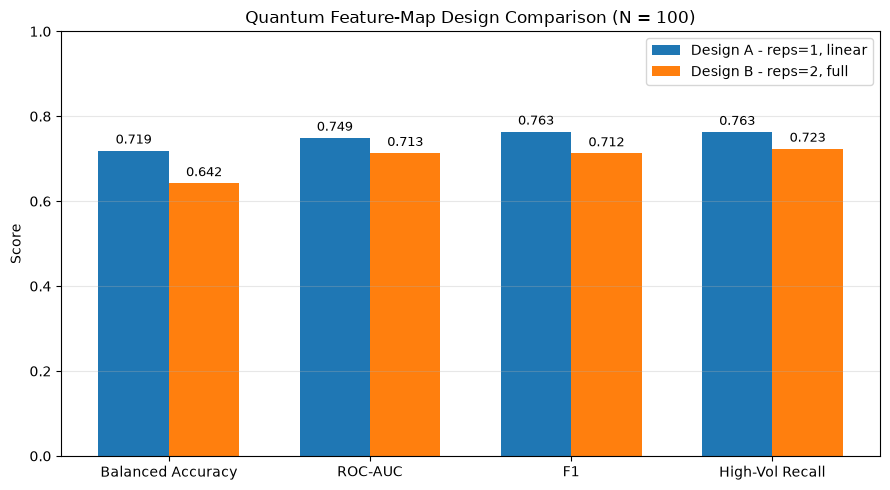

In [88]:
metrics = [
    "Balanced Accuracy",
    "ROC-AUC",
    "F1",
    "High-Vol Recall"
]

design_A_values = design_comparison.loc[0, metrics].astype(float).values
design_B_values = design_comparison.loc[1, metrics].astype(float).values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_a = ax.bar(
    x - width/2,
    design_A_values,
    width,
    label="Design A - reps=1, linear"
)

bars_b = ax.bar(
    x + width/2,
    design_B_values,
    width,
    label="Design B - reps=2, full"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("Score")
ax.set_title("Quantum Feature-Map Design Comparison (N = 100)")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax.bar_label(bars_a, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars_b, fmt="%.3f", padding=3, fontsize=9)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "quantum_design_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Design-choice result

The shallower feature map outperformed the deeper fully entangled design across all predictive metrics.

Increasing circuit depth from 11 to 31 increased both training and prediction simulation runtime substantially, while reducing Balanced Accuracy, ROC-AUC, F1, and high-volatility recall.

For the final quantum model, Design A (`reps=1`, linear entanglement) was therefore selected.

## 13. Final Test Evaluation

In [60]:
test_thin = test.iloc[::H].copy()

print("Full test size:", len(test))
print("Thinned test size:", len(test_thin))
print(
    "Test period:",
    test_thin.index.min(),
    "to",
    test_thin.index.max()
)
print(
    "High-volatility rate:",
    test_thin["high_vol"].mean()
)

Full test size: 497
Thinned test size: 100
Test period: 2023-01-03 00:00:00 to 2024-12-20 00:00:00
High-volatility rate: 0.25


In [61]:
# Persistence baselines on the untouched final test set

test_persistence_results = []

for feature_name, model_name in [
    ("gk_vol_5d", "Persistence 5d"),
    ("gk_vol_20d", "Persistence 20d")
]:
    y_test = test_thin["high_vol"].astype(int)

    score = test_thin[feature_name]
    pred = (score >= high_vol_threshold).astype(int)

    result = {
        "Model": model_name,
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, score),
        "F1": f1_score(y_test, pred),
        "Recall": recall_score(y_test, pred)
    }

    test_persistence_results.append(result)

final_test_persistence = pd.DataFrame(test_persistence_results)

final_test_persistence

,Model,Balanced Accuracy,ROC-AUC,F1,Recall
0,Persistence 5d,0.78,0.834667,0.666667,0.68
1,Persistence 20d,0.68,0.741867,0.518519,0.56


In [62]:
# Rebuild the frozen small-data training windows
# and evaluate them on the untouched 2023–2024 test period.

train_thin_final, _ = thin_data(
    train,
    val,
    H
)

final_window_indices = generate_windows(
    train_thin_final,
    N_values=N_VALUES,
    n_windows=N_WINDOWS
)

test_datasets = prep_small_data(
    train_thin_final,
    test_thin,
    final_window_indices,
    feature_cols,
    N_values=N_VALUES
)

print("Number of final-test datasets:", len(test_datasets))

for dataset in test_datasets:
    (
        X_train_window,
        X_train_scaled,
        y_train_window,
        X_test_window,
        X_test_scaled,
        y_test_window,
        N,
        window_id,
        start_date,
        end_date
    ) = dataset

    print(
        f"N={N}, window={window_id}, "
        f"train={len(X_train_window)}, test={len(X_test_window)}, "
        f"train period={start_date.date()} to {end_date.date()}"
    )

   Dataset  Original size  Thinned size  Thinned high-volatility rate
     Train           2759           552                      0.327899
Validation            498           100                      0.590000


,N,Window,Start,End,High-vol rate
0,20,1,2010-01-11,2010-05-27,0.55
1,20,2,2015-04-24,2015-09-09,0.25
2,20,3,2020-08-05,2020-12-18,0.50


,N,Window,Start,End,High-vol rate
0,50,1,2010-01-11,2010-12-30,0.60
1,50,2,2015-01-06,2015-12-24,0.32
2,50,3,2019-12-31,2020-12-18,0.62


,N,Window,Start,End,High-vol rate
0,100,1,2010-01-11,2011-12-27,0.60
1,100,2,2014-07-09,2016-06-24,0.32
2,100,3,2019-01-03,2020-12-18,0.41


,N,Window,Start,End,High-vol rate
0,200,1,2010-01-11,2013-12-23,0.410
1,200,2,2013-07-11,2017-06-22,0.170
2,200,3,2017-01-06,2020-12-18,0.325


,N,Window,Start,End,Train high-volatility rate
0,20,1,2010-01-11,2010-05-27,0.550
1,20,2,2015-04-24,2015-09-09,0.250
2,20,3,2020-08-05,2020-12-18,0.500
3,50,1,2010-01-11,2010-12-30,0.600
4,50,2,2015-01-06,2015-12-24,0.320
5,50,3,2019-12-31,2020-12-18,0.620
6,100,1,2010-01-11,2011-12-27,0.600
7,100,2,2014-07-09,2016-06-24,0.320
8,100,3,2019-01-03,2020-12-18,0.410
9,200,1,2010-01-11,2013-12-23,0.410


Number of final-test datasets: 12
N=20, window=1, train=20, test=100, train period=2010-01-11 to 2010-05-27
N=20, window=2, train=20, test=100, train period=2015-04-24 to 2015-09-09
N=20, window=3, train=20, test=100, train period=2020-08-05 to 2020-12-18
N=50, window=1, train=50, test=100, train period=2010-01-11 to 2010-12-30
N=50, window=2, train=50, test=100, train period=2015-01-06 to 2015-12-24
N=50, window=3, train=50, test=100, train period=2019-12-31 to 2020-12-18
N=100, window=1, train=100, test=100, train period=2010-01-11 to 2011-12-27
N=100, window=2, train=100, test=100, train period=2014-07-09 to 2016-06-24
N=100, window=3, train=100, test=100, train period=2019-01-03 to 2020-12-18
N=200, window=1, train=200, test=100, train period=2010-01-11 to 2013-12-23
N=200, window=2, train=200, test=100, train period=2013-07-11 to 2017-06-22
N=200, window=3, train=200, test=100, train period=2017-01-06 to 2020-12-18


In [63]:
final_test_rbf_results = small_rbf_svm(
    test_datasets,
    model_name="RBF-SVM",
    split="Test"
)

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,20,1,2010-01-11,2010-05-27,0.005889,0.002096,0.493333,0.768,0.117647,0.08


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,20,2,2015-04-24,2015-09-09,0.005239,0.00144,0.64,0.736533,0.454545,0.4


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,20,3,2020-08-05,2020-12-18,0.002428,0.001266,0.666667,0.809067,0.5,0.44


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,50,1,2010-01-11,2010-12-30,0.002419,0.002643,0.7,0.8208,0.55814,0.48


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,50,2,2015-01-06,2015-12-24,0.002387,0.001669,0.74,0.7952,0.596491,0.68


...

,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,100,2,2014-07-09,2016-06-24,0.005085,0.003612,0.746667,0.811733,0.625,0.6


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,100,3,2019-01-03,2020-12-18,0.005794,0.003645,0.713333,0.783467,0.577778,0.52


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,200,1,2010-01-11,2013-12-23,0.007115,0.003031,0.726667,0.822933,0.595745,0.56


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,200,2,2013-07-11,2017-06-22,0.0064,0.00337,0.78,0.8256,0.644068,0.76


,Data Regime,Split,Model,N,Window,Start Date,End Date,Training Time,Prediction Time,Balanced Accuracy,ROC-AUC,F1,Recall High Volatility
0,Small,Test,RBF-SVM,200,3,2017-01-06,2020-12-18,0.004792,0.003816,0.733333,0.805867,0.586207,0.68


In [64]:
final_test_rbf_aggregated = aggregate_window_metrics(
    final_test_rbf_results
)

final_test_rbf_aggregated

,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Test,Small,RBF-SVM,20,0.004519,0.001601,0.600000,0.093333,0.771200,0.036372,0.357398,0.208870,0.306667,0.197315
1,Test,Small,RBF-SVM,50,0.003005,0.002076,0.666667,0.094516,0.800889,0.017764,0.468210,0.189946,0.440000,0.262298
2,Test,Small,RBF-SVM,100,0.005706,0.003718,0.668889,0.107152,0.807289,0.021940,0.479357,0.212680,0.426667,0.234379
3,Test,Small,RBF-SVM,200,0.006102,0.003406,0.746667,0.029059,0.818133,0.010707,0.608673,0.031021,0.666667,0.100664


,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Test,Small,RBF-SVM,20,0.004519,0.001601,0.600000,0.093333,0.771200,0.036372,0.357398,0.208870,0.306667,0.197315
1,Test,Small,RBF-SVM,50,0.003005,0.002076,0.666667,0.094516,0.800889,0.017764,0.468210,0.189946,0.440000,0.262298
2,Test,Small,RBF-SVM,100,0.005706,0.003718,0.668889,0.107152,0.807289,0.021940,0.479357,0.212680,0.426667,0.234379
3,Test,Small,RBF-SVM,200,0.006102,0.003406,0.746667,0.029059,0.818133,0.010707,0.608673,0.031021,0.666667,0.100664


In [65]:
if RUN_EXPENSIVE_QUANTUM:

    final_test_quantum_results = small_q_svc(
        test_datasets,
        model_name="Quantum SVC - reps1 linear",
        reps=1,
        entanglement="linear",
        split="Test"
    )

In [66]:
FINAL_QUANTUM_RESULTS_FILE = (
    RESULTS_DIR / "final_test_quantum_aggregated.csv"
)

if RUN_EXPENSIVE_QUANTUM:

    final_test_quantum_aggregated = aggregate_window_metrics(
        final_test_quantum_results
    )

    final_test_quantum_aggregated.to_csv(
        FINAL_QUANTUM_RESULTS_FILE,
        index=False
    )

    print("Quantum final test recomputed and saved.")

else:

    if ACTIVE_DATA_SOURCE != SAVED_RESULTS_SOURCE:
        raise RuntimeError(
            "Saved quantum results were generated with Bloomberg volatility, "
            f"but the current notebook is using {ACTIVE_DATA_SOURCE}. "
            "To avoid mixing data sources, either provide the Bloomberg file "
            "or set RUN_EXPENSIVE_QUANTUM = True to recompute the quantum results."
        )

    final_test_quantum_aggregated = pd.read_csv(
        FINAL_QUANTUM_RESULTS_FILE
    )

    print("Loaded saved quantum final-test results.")

final_test_quantum_aggregated

Loaded saved quantum final-test results.


,split,data_regime,model_name,N,avg_training_time,avg_prediction_time,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,Test,Small,Quantum SVC - reps1 linear,20,0.974064,26.839387,0.551111,0.075817,0.593067,0.008812,0.346897,0.151584,0.546667,0.349476
1,Test,Small,Quantum SVC - reps1 linear,50,6.905105,46.217281,0.615556,0.091003,0.656356,0.114647,0.446886,0.108948,0.560000,0.080000
2,Test,Small,Quantum SVC - reps1 linear,100,25.064770,153.405676,0.653333,0.087433,0.683378,0.095352,0.479909,0.107831,0.586667,0.161658
3,Test,Small,Quantum SVC - reps1 linear,200,182.657000,376.645580,0.711111,0.033555,0.748800,0.049197,0.552400,0.035502,0.680000,0.105830


In [67]:
final_test_rbf_aggregated.to_csv(
    RESULTS_DIR / "final_test_rbf_aggregated.csv",
    index=False
)

print("Final RBF test results saved.")

Final RBF test results saved.


In [68]:
final_comparison = final_test_rbf_aggregated[
    [
        "N",
        "balanced_accuracy_mean",
        "roc_auc_mean",
        "f1_mean",
        "recall_mean",
        "avg_training_time",
        "avg_prediction_time"
    ]
].merge(
    final_test_quantum_aggregated[
        [
            "N",
            "balanced_accuracy_mean",
            "roc_auc_mean",
            "f1_mean",
            "recall_mean",
            "avg_training_time",
            "avg_prediction_time"
        ]
    ],
    on="N",
    suffixes=("_rbf", "_quantum")
)

final_comparison.to_csv(
    RESULTS_DIR / "final_test_rbf_vs_quantum.csv",
    index=False
)

final_comparison

,N,balanced_accuracy_mean_rbf,roc_auc_mean_rbf,f1_mean_rbf,recall_mean_rbf,avg_training_time_rbf,avg_prediction_time_rbf,balanced_accuracy_mean_quantum,roc_auc_mean_quantum,f1_mean_quantum,recall_mean_quantum,avg_training_time_quantum,avg_prediction_time_quantum
0,20,0.600000,0.771200,0.357398,0.306667,0.004519,0.001601,0.551111,0.593067,0.346897,0.546667,0.974064,26.839387
1,50,0.666667,0.800889,0.468210,0.440000,0.003005,0.002076,0.615556,0.656356,0.446886,0.560000,6.905105,46.217281
2,100,0.668889,0.807289,0.479357,0.426667,0.005706,0.003718,0.653333,0.683378,0.479909,0.586667,25.064770,153.405676
3,200,0.746667,0.818133,0.608673,0.666667,0.006102,0.003406,0.711111,0.748800,0.552400,0.680000,182.657000,376.645580


In [69]:
# Build a compact final benchmark table

final_benchmark_table = pd.DataFrame([
    {
        "Model": "Persistence 5d",
        "N": "N/A",
        "Balanced Accuracy": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 5d",
            "Balanced Accuracy"
        ].iloc[0],
        "ROC-AUC": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 5d",
            "ROC-AUC"
        ].iloc[0],
        "F1": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 5d",
            "F1"
        ].iloc[0],
        "Recall": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 5d",
            "Recall"
        ].iloc[0]
    },

    {
        "Model": "Persistence 20d",
        "N": "N/A",
        "Balanced Accuracy": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 20d",
            "Balanced Accuracy"
        ].iloc[0],
        "ROC-AUC": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 20d",
            "ROC-AUC"
        ].iloc[0],
        "F1": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 20d",
            "F1"
        ].iloc[0],
        "Recall": final_test_persistence.loc[
            final_test_persistence["Model"] == "Persistence 20d",
            "Recall"
        ].iloc[0]
    },

    {
        "Model": "RBF-SVM",
        "N": 200,
        "Balanced Accuracy": final_comparison.loc[
            final_comparison["N"] == 200,
            "balanced_accuracy_mean_rbf"
        ].iloc[0],
        "ROC-AUC": final_comparison.loc[
            final_comparison["N"] == 200,
            "roc_auc_mean_rbf"
        ].iloc[0],
        "F1": final_comparison.loc[
            final_comparison["N"] == 200,
            "f1_mean_rbf"
        ].iloc[0],
        "Recall": final_comparison.loc[
            final_comparison["N"] == 200,
            "recall_mean_rbf"
        ].iloc[0]
    },

    {
        "Model": "Quantum SVC",
        "N": 200,
        "Balanced Accuracy": final_comparison.loc[
            final_comparison["N"] == 200,
            "balanced_accuracy_mean_quantum"
        ].iloc[0],
        "ROC-AUC": final_comparison.loc[
            final_comparison["N"] == 200,
            "roc_auc_mean_quantum"
        ].iloc[0],
        "F1": final_comparison.loc[
            final_comparison["N"] == 200,
            "f1_mean_quantum"
        ].iloc[0],
        "Recall": final_comparison.loc[
            final_comparison["N"] == 200,
            "recall_mean_quantum"
        ].iloc[0]
    }
])

final_benchmark_table.round(3)

,Model,N,Balanced Accuracy,ROC-AUC,F1,Recall
0,Persistence 5d,N/A,0.780,0.835,0.667,0.680
1,Persistence 20d,N/A,0.680,0.742,0.519,0.560
2,RBF-SVM,200,0.747,0.818,0.609,0.667
3,Quantum SVC,200,0.711,0.749,0.552,0.680


### Final benchmark interpretation

The 5-day persistence baseline is a particularly strong benchmark on the untouched 2023–2024 test period.

At N = 200, it achieves higher Balanced Accuracy, ROC-AUC, and F1 than both learned models. This indicates that short-horizon volatility persistence is difficult to beat in this setting.

Among the learned models, the classical RBF-SVM remains stronger than the Quantum SVC on overall discrimination.

The Quantum SVC reaches the same mean high-volatility recall as the 5-day persistence baseline at N = 200, but its lower ROC-AUC and Balanced Accuracy indicate that this should not be interpreted as superior overall detection performance.

The persistence baseline does not use a training-set budget N, so it is best interpreted as a simple domain-specific reference rather than a directly matched learned model.

In [70]:
final_benchmark_table.to_csv(
    RESULTS_DIR / "final_test_benchmark_table.csv",
    index=False
)

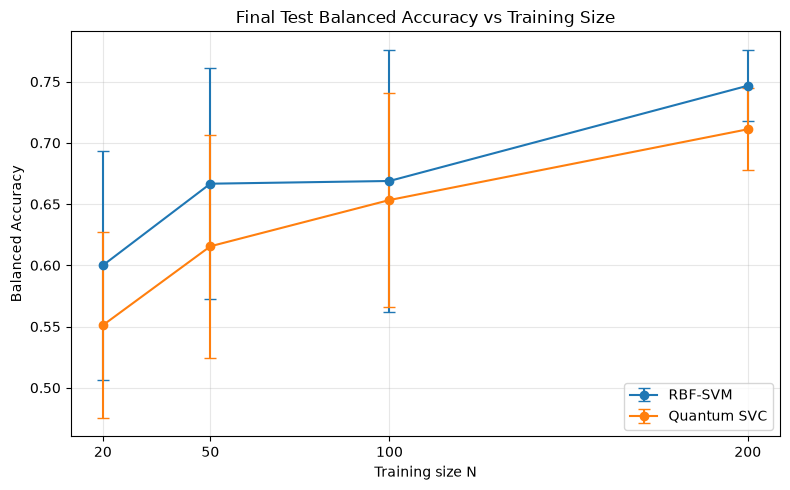

In [71]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    final_test_rbf_aggregated["N"],
    final_test_rbf_aggregated["balanced_accuracy_mean"],
    yerr=final_test_rbf_aggregated["balanced_accuracy_std"],
    marker="o",
    capsize=4,
    label="RBF-SVM"
)

plt.errorbar(
    final_test_quantum_aggregated["N"],
    final_test_quantum_aggregated["balanced_accuracy_mean"],
    yerr=final_test_quantum_aggregated["balanced_accuracy_std"],
    marker="o",
    capsize=4,
    label="Quantum SVC"
)

plt.xlabel("Training size N")
plt.ylabel("Balanced Accuracy")
plt.title("Final Test Balanced Accuracy vs Training Size")
plt.xticks(final_test_rbf_aggregated["N"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "final_test_balanced_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

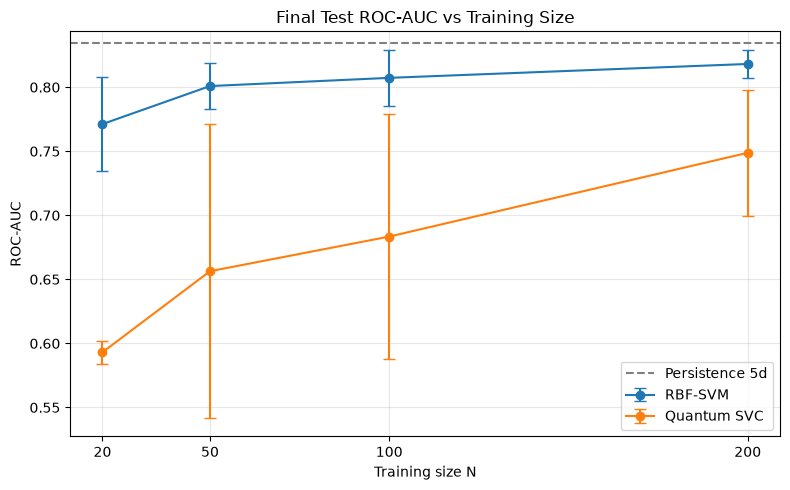

In [82]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    final_test_rbf_aggregated["N"],
    final_test_rbf_aggregated["roc_auc_mean"],
    yerr=final_test_rbf_aggregated["roc_auc_std"],
    marker="o",
    capsize=4,
    label="RBF-SVM"
)

plt.errorbar(
    final_test_quantum_aggregated["N"],
    final_test_quantum_aggregated["roc_auc_mean"],
    yerr=final_test_quantum_aggregated["roc_auc_std"],
    marker="o",
    capsize=4,
    label="Quantum SVC"
)

p5 = (
    final_test_persistence
    .set_index("Model")
    .loc["Persistence 5d", "ROC-AUC"]
)

plt.axhline(
    p5,
    linestyle="--",
    color="gray",
    label="Persistence 5d"
)

plt.xlabel("Training size N")
plt.ylabel("ROC-AUC")
plt.title("Final Test ROC-AUC vs Training Size")
plt.xticks(final_test_rbf_aggregated["N"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "final_test_roc_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Uncertainty note

Error bars represent the standard deviation across the three chronological training windows for each training size.

They summarize sensitivity to the selected historical training window and should not be interpreted as formal confidence intervals.

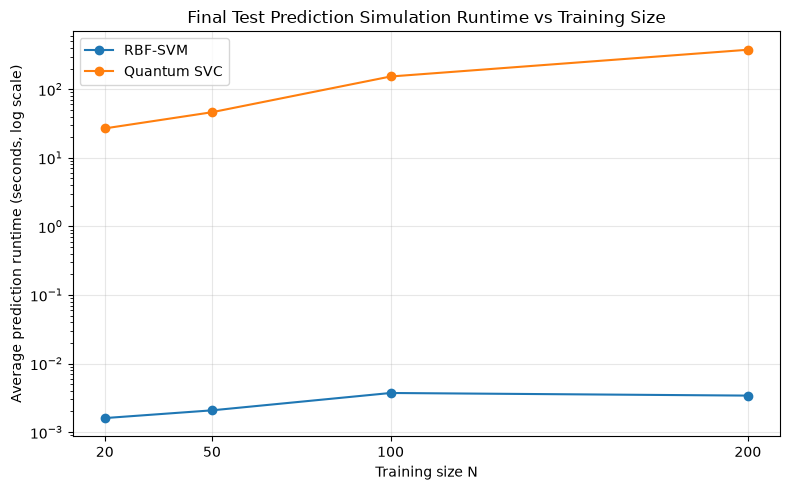

In [83]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_comparison["N"],
    final_comparison["avg_prediction_time_rbf"],
    marker="o",
    label="RBF-SVM"
)

plt.plot(
    final_comparison["N"],
    final_comparison["avg_prediction_time_quantum"],
    marker="o",
    label="Quantum SVC"
)

plt.yscale("log")

plt.xlabel("Training size N")
plt.ylabel("Average prediction runtime (seconds, log scale)")
plt.title("Final Test Prediction Simulation Runtime vs Training Size")
plt.xticks(final_comparison["N"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "final_test_prediction_runtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

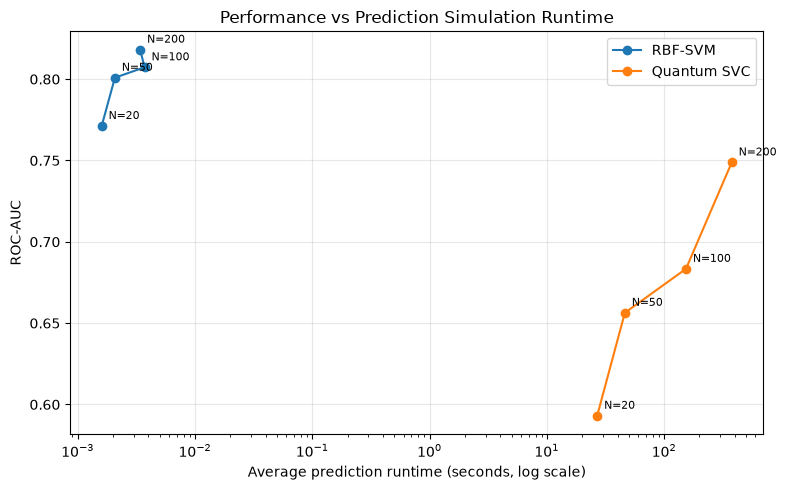

In [84]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_comparison["avg_prediction_time_rbf"],
    final_comparison["roc_auc_mean_rbf"],
    marker="o",
    label="RBF-SVM"
)

plt.plot(
    final_comparison["avg_prediction_time_quantum"],
    final_comparison["roc_auc_mean_quantum"],
    marker="o",
    label="Quantum SVC"
)

for _, row in final_comparison.iterrows():
    plt.annotate(
        f"N={int(row['N'])}",
        (
            row["avg_prediction_time_rbf"],
            row["roc_auc_mean_rbf"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

    plt.annotate(
        f"N={int(row['N'])}",
        (
            row["avg_prediction_time_quantum"],
            row["roc_auc_mean_quantum"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xscale("log")
plt.xlabel("Average prediction runtime (seconds, log scale)")
plt.ylabel("ROC-AUC")
plt.title("Performance vs Prediction Simulation Runtime")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "performance_vs_prediction_runtime.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

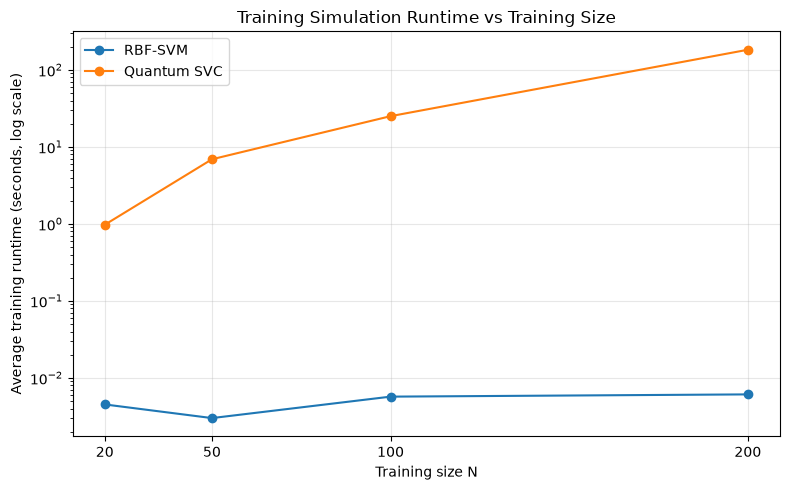

In [85]:
plt.figure(figsize=(8, 5))

plt.plot(
    final_comparison["N"],
    final_comparison["avg_training_time_rbf"],
    marker="o",
    label="RBF-SVM"
)

plt.plot(
    final_comparison["N"],
    final_comparison["avg_training_time_quantum"],
    marker="o",
    label="Quantum SVC"
)

plt.yscale("log")

plt.xlabel("Training size N")
plt.ylabel("Average training runtime (seconds, log scale)")
plt.title("Training Simulation Runtime vs Training Size")
plt.xticks(final_comparison["N"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "training_simulation_runtime.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

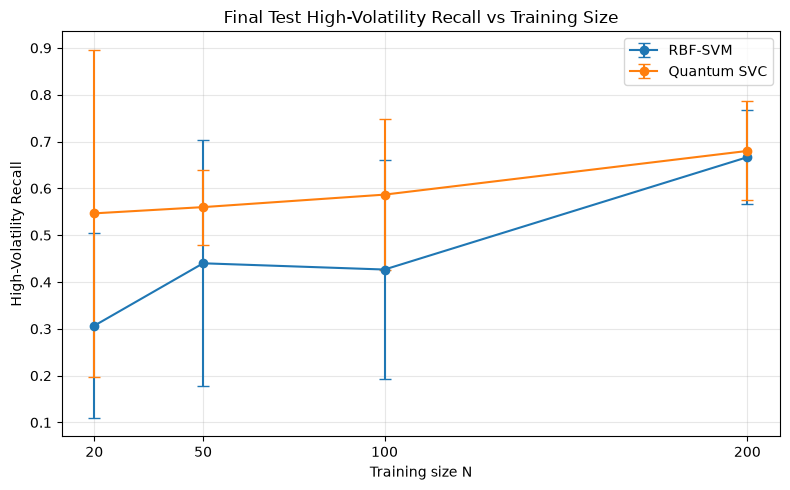

In [86]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    final_test_rbf_aggregated["N"],
    final_test_rbf_aggregated["recall_mean"],
    yerr=final_test_rbf_aggregated["recall_std"],
    marker="o",
    capsize=4,
    label="RBF-SVM"
)

plt.errorbar(
    final_test_quantum_aggregated["N"],
    final_test_quantum_aggregated["recall_mean"],
    yerr=final_test_quantum_aggregated["recall_std"],
    marker="o",
    capsize=4,
    label="Quantum SVC"
)

plt.xlabel("Training size N")
plt.ylabel("High-Volatility Recall")
plt.title("Final Test High-Volatility Recall vs Training Size")
plt.xticks(final_test_rbf_aggregated["N"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "final_test_high_vol_recall.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

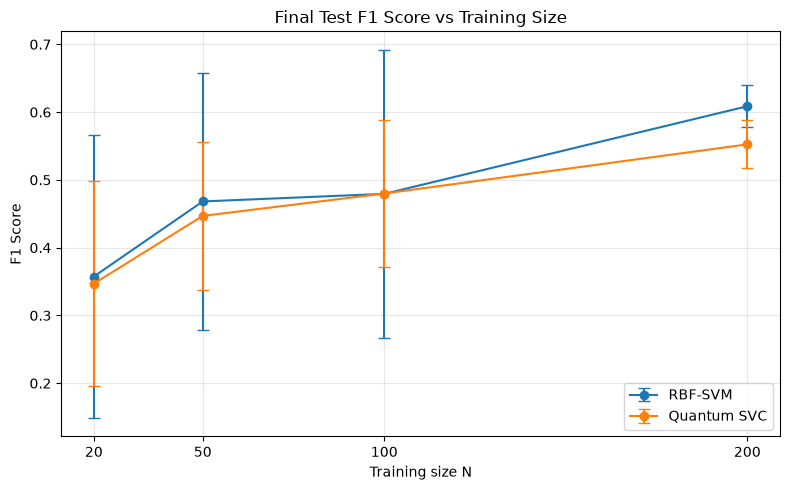

In [87]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    final_test_rbf_aggregated["N"],
    final_test_rbf_aggregated["f1_mean"],
    yerr=final_test_rbf_aggregated["f1_std"],
    marker="o",
    capsize=4,
    label="RBF-SVM"
)

plt.errorbar(
    final_test_quantum_aggregated["N"],
    final_test_quantum_aggregated["f1_mean"],
    yerr=final_test_quantum_aggregated["f1_std"],
    marker="o",
    capsize=4,
    label="Quantum SVC"
)

plt.xlabel("Training size N")
plt.ylabel("F1 Score")
plt.title("Final Test F1 Score vs Training Size")
plt.xticks(final_test_rbf_aggregated["N"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "final_test_f1_score.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Final Interpretation

On the untouched 2023–2024 test period, the classical RBF-SVM achieved higher Balanced Accuracy and ROC-AUC than the Quantum SVC across all tested training sizes.

The Quantum SVC generally improved as the training size increased, but it did not outperform the classical RBF-SVM on overall discrimination.

The 5-day persistence baseline was particularly strong on the final test period. At N = 200, it achieved higher Balanced Accuracy, ROC-AUC, and F1 than both learned models. This indicates that short-horizon volatility persistence is difficult to beat in this setting.

The Quantum SVC showed slightly higher mean high-volatility recall than the RBF-SVM for several training sizes, including N = 200. However, this is a threshold-dependent metric, and the difference at N = 200 is small. Because the Quantum SVC also had lower ROC-AUC and Balanced Accuracy, the higher recall should not be interpreted as superior overall detection performance.

The controlled quantum feature-map experiment showed that increasing feature-map complexity from a shallow linear-entanglement design to a deeper fully entangled design increased circuit depth and simulation runtime while reducing validation performance.

The uncertainty analysis also shows that performance varies across chronological training windows, particularly in the small-data regime. Error bars therefore represent sensitivity to the historical training period rather than formal confidence intervals.

### Conclusion

No quantum advantage was observed in this experiment.

Under the tested configuration, the classical RBF-SVM remained stronger than the Quantum SVC on overall discrimination, while the simple 5-day persistence baseline was the strongest final-test benchmark on several metrics.

The Quantum SVC achieved non-random predictive performance and improved as the training budget increased, but its performance remained sensitive to the historical training window and below the strongest classical and persistence baselines.

These findings apply only to the specific feature representation, scaling strategy, quantum feature map, classifier settings, and simulator configuration evaluated here. They should not be interpreted as a general limitation of quantum-kernel methods.

Future work could investigate alternative quantum encodings, feature scaling ranges, statevector-specific kernel implementations, finite-shot or noisy simulation, and execution on real quantum hardware.

## Appendix: Optional Macro and VIX Feature Extensions

In [78]:
if RUN_OPTIONAL_MACRO_EXTENSION:

    # --- 2Y / 10Y yields and spread ---

    rates_2_10 = pd.read_csv(
        RAW_DIR / "spread 2-10.csv"
    )

    rates_2_10["Date"] = pd.to_datetime(
        rates_2_10["Date"]
    )

    rates_2_10 = rates_2_10.rename(columns={
        "USGG2YR Index": "yield_2y",
        "USGG10YR Index": "yield_10y",
        "USGG2YR Index - USGG10YR Index": "spread_2y_10y_bps"
    })

    rates_2_10 = (
        rates_2_10
        .set_index("Date")
        .sort_index()
    )

    print("2Y/10Y:")
    print(rates_2_10.head())
    print("Shape:", rates_2_10.shape)

else:

    print("Optional 2Y/10Y macro extension skipped.")

Optional 2Y/10Y macro extension skipped.


In [79]:
if RUN_OPTIONAL_MACRO_EXTENSION:

    # --- VIX ---

    vix = pd.read_csv(
        RAW_DIR / "VIX.csv",
        skiprows=1
    )

    vix.columns = ["Date", "vix"]

    vix["Date"] = pd.to_datetime(
        vix["Date"],
        errors="coerce"
    )

    vix["vix"] = pd.to_numeric(
        vix["vix"],
        errors="coerce"
    )

    vix = (
        vix
        .dropna(subset=["Date"])
        .set_index("Date")
        .sort_index()
    )

    print("VIX:")
    print(vix.head())
    print("Shape:", vix.shape)
    print("Range:", vix.index.min(), "to", vix.index.max())
    print("Missing:", vix.isna().sum())

else:

    print("Optional macro/VIX extension skipped.")

Optional macro/VIX extension skipped.


In [80]:
if RUN_OPTIONAL_MACRO_EXTENSION:

    # --- 3-month Treasury yield ---

    rate_3m = pd.read_csv(
        RAW_DIR / "3M-2024-2010.csv",
        skiprows=5
    )

    rate_3m = rate_3m.rename(columns={
        "PX_LAST": "yield_3m"
    })

    rate_3m["Date"] = pd.to_datetime(
        rate_3m["Date"],
        errors="coerce"
    )

    rate_3m["yield_3m"] = pd.to_numeric(
        rate_3m["yield_3m"],
        errors="coerce"
    )

    rate_3m = (
        rate_3m[
            ["Date", "yield_3m"]
        ]
        .dropna(subset=["Date"])
        .set_index("Date")
        .sort_index()
    )

    print("3M Treasury:")
    print(rate_3m.head())
    print("Shape:", rate_3m.shape)
    print("Range:", rate_3m.index.min(), "to", rate_3m.index.max())
    print("Missing:", rate_3m.isna().sum())

    print("SPX dates:", len(data.index))
    print("VIX dates:", len(vix.index))
    print("3M dates:", len(rate_3m.index))
    print("2Y/10Y dates:", len(rates_2_10.index))

    print(
        "\nSPX dates missing in VIX:",
        len(data.index.difference(vix.index))
    )

    print(
        "SPX dates missing in 3M:",
        len(data.index.difference(rate_3m.index))
    )

    print(
        "SPX dates missing in 2Y/10Y:",
        len(data.index.difference(rates_2_10.index))
    )

    data_extended = (
        data
        .join(vix, how="left")
        .join(rate_3m, how="left")
        .join(
            rates_2_10[
                ["yield_2y", "yield_10y", "spread_2y_10y_bps"]
            ],
            how="left"
        )
    )

    print("Extended shape:", data_extended.shape)

    print("\nMissing values before fill:")
    print(
        data_extended[
            [
                "vix",
                "yield_3m",
                "yield_2y",
                "yield_10y",
                "spread_2y_10y_bps"
            ]
        ].isna().sum()
    )

    rate_cols = [
        "yield_2y",
        "yield_10y",
        "spread_2y_10y_bps"
    ]

    data_extended[rate_cols] = (
        data_extended[rate_cols]
        .ffill()
    )

    print("\nMissing values after forward-fill:")
    print(
        data_extended[
            [
                "vix",
                "yield_3m",
                "yield_2y",
                "yield_10y",
                "spread_2y_10y_bps"
            ]
        ].isna().sum()
    )

    core_feature_cols = [
        "return_1d",
        "momentum_5d",
        "gk_vol_5d",
        "gk_vol_20d",
        "vix"
    ]

    extended_feature_cols = [
        "return_1d",
        "momentum_5d",
        "gk_vol_5d",
        "gk_vol_20d",
        "vix",
        "yield_3m",
        "spread_2y_10y_bps"
    ]

    model_data_extended = data_extended[
        extended_feature_cols
        + ["future_gk_vol_5d", "high_vol"]
    ].dropna().copy()

    train_ext = model_data_extended.loc[
        "2010-01-01":"2020-12-31"
    ].iloc[:-H].copy()

    val_ext = model_data_extended.loc[
        "2021-01-01":"2022-12-31"
    ].iloc[:-H].copy()

    test_ext = model_data_extended.loc[
        "2023-01-01":"2024-12-31"
    ].copy()

    print("Train:", train_ext.shape)
    print("Validation:", val_ext.shape)
    print("Test:", test_ext.shape)

    base_4_features = [
        "return_1d",
        "momentum_5d",
        "gk_vol_5d",
        "gk_vol_20d"
    ]

    core_5_features = [
        "return_1d",
        "momentum_5d",
        "gk_vol_5d",
        "gk_vol_20d",
        "vix"
    ]

else:

    print("Optional macro/VIX extension skipped.")

Optional macro/VIX extension skipped.


### Optional feature-extension experiment

This section compares the final 4-feature specification with an extended 5-feature version including VIX.

The extension was not rerun as part of the final submission because the main feature set had already been selected on validation and the final quantum test was completed with the frozen 4-feature configuration.

The code is retained for reproducibility and future experimentation.

In [81]:

def evaluate_feature_set(train, val, feature_set, name):

    # Prepare the requested train/validation data
    X_train, y_train, X_val, y_val = prep_data(
        train,
        val,
        feature_set
    )

    # Same scaling for classical and quantum models
    X_train_scaled, X_val_scaled, start_date, end_date = scale_X(
        X_train,
        X_val
    )

    # Persistence baselines
    persistence_baseline_with_threshold(
        X_val,
        y_val,
        threshold=THRESHOLD
    )

    # Full classical RBF-SVM
    rbf_results = rbf_svc_baseline(
        X_train_scaled=X_train_scaled,
        X_val_scaled=X_val_scaled,
        X_val=X_val,
        y_val=y_val,
        y_train=y_train,
        start_date=start_date,
        end_date=end_date,
        model_name=f"RBF-SVM ({name})",
        regime="Classical"
    )

    # Small-data regime
    train_thin, val_thin = thin_data(
        train,
        val,
        H
    )

    window_indices = generate_windows(
        train_thin,
        N_values=N_VALUES,
        n_windows=N_WINDOWS
    )

    datasets = prep_small_data(
        train_thin,
        val_thin,
        window_indices,
        feature_set,
        N_values=N_VALUES
    )

    # Small-data classical
    small_rbf_results = small_rbf_svm(
        datasets,
        model_name=f"RBF-SVM ({name})"
    )

    small_rbf_aggregated_results = aggregate_window_metrics(
        small_rbf_results
    )

    # Small-data quantum
    quantum_results = small_q_svc(
        datasets,
        model_name=f"Quantum SVC ({name})",
        reps=1,
        entanglement="linear"
    )

    quantum_aggregated_results = aggregate_window_metrics(
        quantum_results
    )

    return {
        "rbf_full": rbf_results,
        "rbf_small": small_rbf_results,
        "rbf_small_aggregated": small_rbf_aggregated_results,
        "quantum_small": quantum_results,
        "quantum_small_aggregated": quantum_aggregated_results,
        "datasets": datasets
    }
# Optional extension:
# evaluate_feature_set(train_ext, val_ext, base_4_features, "Base 4 features")
# evaluate_feature_set(train_ext, val_ext, core_5_features, "Core 5 features + VIX")